In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import json
import os
import glob
import matplotlib.dates as mdates
import seaborn as sns

<jemalloc>: MADV_DONTNEED does not work (memset will be used instead)
<jemalloc>: (This is the expected behaviour if you are running under QEMU)


### Occupancy plots

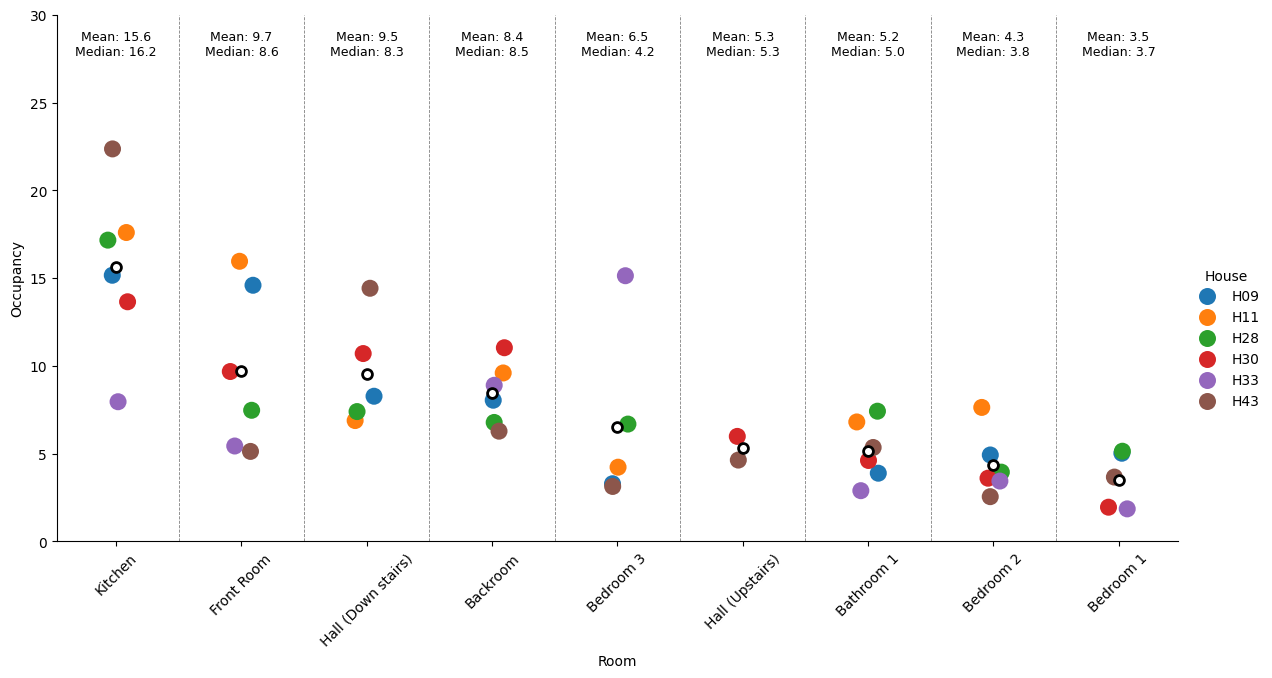

In [5]:
def calculate_yearly_occupancy_distribution(df):
    df['UTC_Time'] = pd.to_datetime(df['UTC_Time'])
    waking_hours_data = df.set_index('UTC_Time').between_time('06:00', '23:00')
    occupancy_distribution = {}
    for room in rooms:
        if room in waking_hours_data.columns:
            occupied_count = len(waking_hours_data[waking_hours_data[room] > 0])
            total_count = len(waking_hours_data)
            occupancy_percentage = (occupied_count / total_count) * 100 if total_count > 0 else 0
            occupancy_distribution[room] = occupancy_percentage
        else:
            occupancy_distribution[room] = None
    return occupancy_distribution

directory = "/workspaces/CUBES/exp/jack/paper/thermostat_experiment/SI/generate_occupancy/mapped_schedules"
rooms = [
    'hall_downstairs', 'hall_upstairs', 'front_room', 'kitchen', 'backroom',
    'bedroom_1', 'bedroom_2', 'bedroom_3', 'bathroom'
]
mapping = {
    'Hall (Down stairs)': 'hall_downstairs', 'Hall (Upstairs)': 'hall_upstairs',
    'Front Room': 'front_room', 'Kitchen': 'kitchen', 'Backroom': 'backroom',
    'Bedroom 1': 'bedroom_1', 'Bedroom 2': 'bedroom_2',
    'Bedroom 3': 'bedroom_3', 'Bathroom 1': 'bathroom'
}
reverse_mapping = {v: k for k, v in mapping.items()}



csv_files = glob.glob(os.path.join(directory, "*.csv"))

house_dataframes = {}
for file in csv_files:
    house_name = os.path.basename(file).split('_')[1]
    house_df = pd.read_csv(file)
    house_df.columns = house_df.columns.str.replace(r'^H\d{2}_', '', regex=True)
    house_df.rename(columns=mapping, inplace=True)
    house_dataframes[house_name] = house_df




csv_files = glob.glob(os.path.join(directory, "*.csv"))

house_dataframes = {}
for file in csv_files:
    house_name = os.path.basename(file).split('_')[1]
    house_df = pd.read_csv(file)
    house_df.columns = house_df.columns.str.replace(r'^H\d{2}_', '', regex=True)
    house_df.rename(columns=mapping, inplace=True)
    house_dataframes[house_name] = house_df


house_dataframes = dict(sorted(house_dataframes.items(), key=lambda item: item[0]))
occupancy_distributions = {house: calculate_yearly_occupancy_distribution(df) for house, df in house_dataframes.items()}

long_df = pd.DataFrame({
    'Room': list(occupancy_distributions[next(iter(occupancy_distributions))].keys()) * len(occupancy_distributions),
    'Occupancy': [value for dist in occupancy_distributions.values() for value in dist.values()],
    'House': [house for house in occupancy_distributions.keys() for _ in occupancy_distributions[house].values()]
})
long_df = long_df[long_df['Occupancy'].notna()]

room_order = long_df.groupby('Room')['Occupancy'].mean().sort_values(ascending=False).index




# Assuming 'long_df', 'room_order', and 'reverse_mapping' are predefined
g = sns.catplot(
    data=long_df, x='Room', y='Occupancy', hue='House', kind='strip', height=6, aspect=2,
    order=room_order, s=150
)

# Set x-tick labels
updated_labels = [reverse_mapping.get(room, room) for room in room_order]
g.set_xticklabels(updated_labels, rotation=45)

# Calculate means and medians
room_stats = long_df.groupby('Room')['Occupancy'].agg(['mean', 'median'])

# Overlay hollow points for means with higher zorder
sns.scatterplot(
    x=room_stats.index, y=room_stats['mean'], marker='o', edgecolor='black', s=50,
    linewidth=2, color='white', ax=g.ax, label='Mean', legend=False, zorder=3
)

# Annotate text for mean and median
for index, row in room_stats.iterrows():
    g.ax.text(
        x=room_order.get_loc(index), y=27.5, s=f"Mean: {row['mean']:.1f}\nMedian: {row['median']:.1f}",
        ha='center', va='bottom', fontsize=9, color='black'
    )

# Add vertical separators to distinguish rooms
for i in range(len(room_order) - 1):
    plt.axvline(x=i + 0.5, color='grey', linestyle='--', linewidth=0.6)  # Add a vertical dashed line between each room

g.ax.set_ylim(0, 30)

plt.savefig("/workspaces/CUBES/exp/jack/paper/thermostat_experiment/figures/SI/occupancy_plot.pdf")
plt.show()


### Holidays

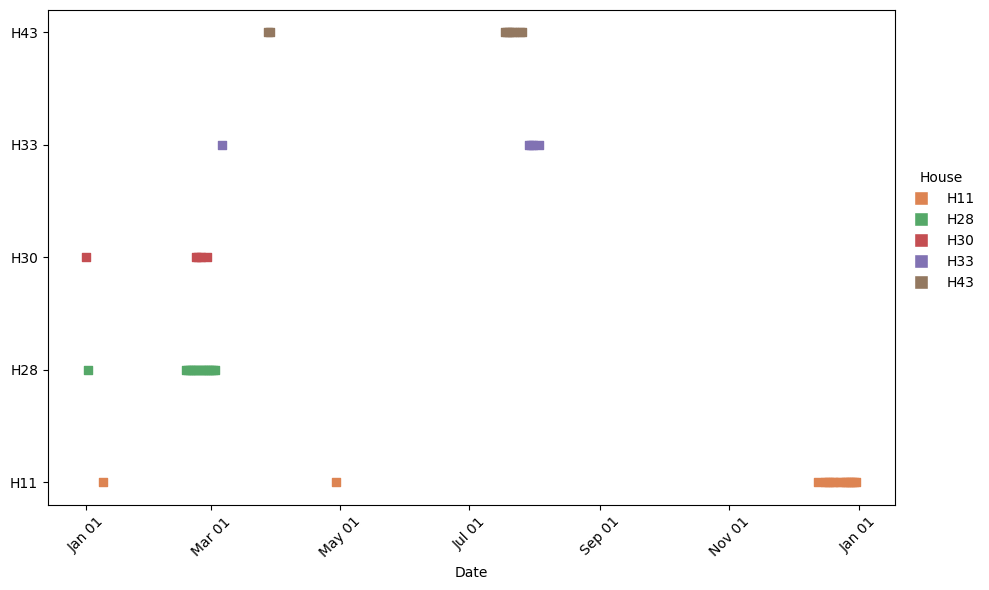

In [6]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def plot_holidays():
    # Define the holiday mapping
    holiday_mapping = {
        "H11": [(1, 9), (4, 29), (12, 13), (12, 16), (12, 17), (12, 18), (12, 20), (12, 21),
                (12, 23), (12, 25), (12, 26), (12, 27), (12, 28), (12, 29), (12, 30), (12, 31)],
        "H28": [(1, 2), (2, 17), (2, 18), (2, 19), (2, 20), (2, 21), (2, 22), (2, 23),
                (2, 24), (2, 25), (2, 26), (2, 27), (2, 28), (3, 1), (3, 2), (3, 3)],
        "H30": [(1, 1), (2, 22), (2, 23), (2, 24), (2, 27)],
        "H33": [(3, 6), (7, 29), (7, 30), (7, 31), (8, 3)],
        "H43": [(3, 28), (3, 29), (7, 18), (7, 19), (7, 20), (7, 21), (7, 22), (7, 25), (7, 26)],
    }

    # Define the colour mapping
    colour_mapping = {
        "H11": "#DD8452",  # Orange
        "H28": "#55A868",  # Green
        "H30": "#C44E52",  # Red
        "H33": "#8172B3",  # Purple
        "H43": "#937860",  # Brown
    }

    # Create figure and axis
    fig, ax = plt.subplots(figsize=(10, 6))

    # Set y-ticks based on the number of IDs
    y_labels = list(holiday_mapping.keys())
    y_pos = np.arange(len(y_labels))

    # Plot the holidays for each ID
    for i, (holiday_id, holidays) in enumerate(holiday_mapping.items()):
        for (month, day) in holidays:
            ax.scatter(
                pd.Timestamp(year=2023, month=month, day=day),
                y_pos[i],
                marker='s',
                color=colour_mapping[holiday_id]
            )

    # Customise the plot
    ax.set_yticks(y_pos)
    ax.set_yticklabels(y_labels)
    ax.set_xlabel('Date')

    # Set x-axis to show month/day format
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %d'))

    # Rotate x-axis labels for better readability
    plt.xticks(rotation=45)

    # Manually create a custom legend with one entry per house
    legend_handles = [
        plt.Line2D([0], [0], marker='s', color='w', markerfacecolor=colour_mapping[house], markersize=10, label=house)
        for house in holiday_mapping.keys()
    ]
    plt.legend(handles=legend_handles, title="House", loc='upper left', bbox_to_anchor=(1, 0.7),
               frameon=False)

    # Use tight_layout to adjust spacing
    plt.tight_layout()

    plt.savefig("/workspaces/CUBES/exp/jack/paper/thermostat_experiment/figures/SI/holiday_plot.pdf")

    # Show plot
    plt.show()

plot_holidays()


### Tariff plot

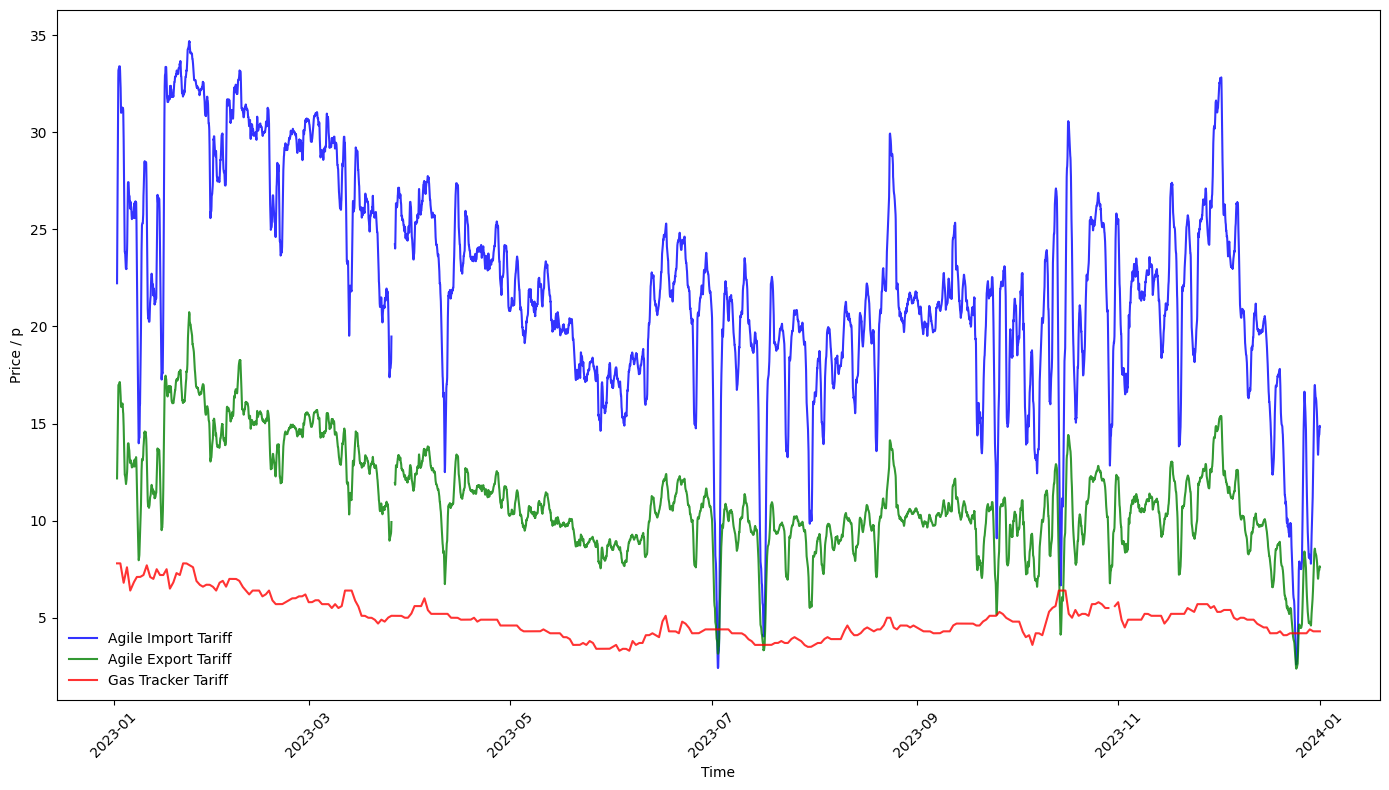

In [4]:

gas_tariff = pd.read_csv("/workspaces/CUBES/cubes/data/gas/gas_tracker.csv", parse_dates=["Time"], index_col=0)
import_tariff = pd.read_csv("/workspaces/CUBES/cubes/data/electricity_import/agile_import.csv", parse_dates=["Time"], index_col=0)
export_tariff = pd.read_csv("/workspaces/CUBES/cubes/data/electricity_export/agile_export.csv", parse_dates=["Time"], index_col=0)

gas_tariff.index = pd.to_datetime(gas_tariff.index)
import_tariff.index = pd.to_datetime(import_tariff.index, dayfirst=True)
export_tariff.index = pd.to_datetime(export_tariff.index, dayfirst=True)



def plot_tariffs_smoothed(gas_tariff, import_tariff, export_tariff, smoothing_window=24):

    # Resample to hourly for import and export tariffs (mean of every 30 mins interval)
    import_tariff_resampled = import_tariff.resample('h').mean()
    export_tariff_resampled = export_tariff.resample('h').mean()

    # Apply smoothing (rolling average) to all tariffs
    gas_tariff_smoothed = gas_tariff.rolling(window=smoothing_window).mean()
    import_tariff_smoothed = import_tariff_resampled.rolling(window=smoothing_window).mean()
    export_tariff_smoothed = export_tariff_resampled.rolling(window=smoothing_window).mean()

    # Set the figure size
    plt.figure(figsize=(14, 8))


    # Plot electricity import tariff (smoothed)
    plt.plot(import_tariff_smoothed.index, import_tariff_smoothed['price'], label='Agile Import Tariff', color='blue', alpha=0.8, linewidth=1.5)

    # Plot electricity export tariff (smoothed)
    plt.plot(export_tariff_smoothed.index, export_tariff_smoothed['price'], label='Agile Export Tariff', color='green', alpha=0.8, linewidth=1.5)

    # Plot gas tariff
    plt.plot(gas_tariff_smoothed.index, gas_tariff_smoothed['price'], label='Gas Tracker Tariff', color='red', alpha=0.8, linewidth=1.5)

    # Set x-axis labels and format
    plt.xlabel('Time')
    plt.ylabel('Price / p')
    # plt.title('Gas, Electricity Import, and Export Tariffs in 2023 (Smoothed)')

    # Set x-axis to display time more clearly
    plt.xticks(rotation=45)

    # Display legend
    plt.legend(frameon=False)

    # Show grid
    #plt.grid(True)

    plt.savefig("/workspaces/CUBES/exp/jack/paper/thermostat_experiment/figures/SI/tariff_plot.pdf")



    # Display the plot
    plt.tight_layout()
    plt.show()



plot_tariffs_smoothed(gas_tariff, import_tariff, export_tariff)


### Real occupancy

In [3]:
occ = pd.read_csv("/workspaces/CUBES/cubes/data/occupants/rep_0.sch")

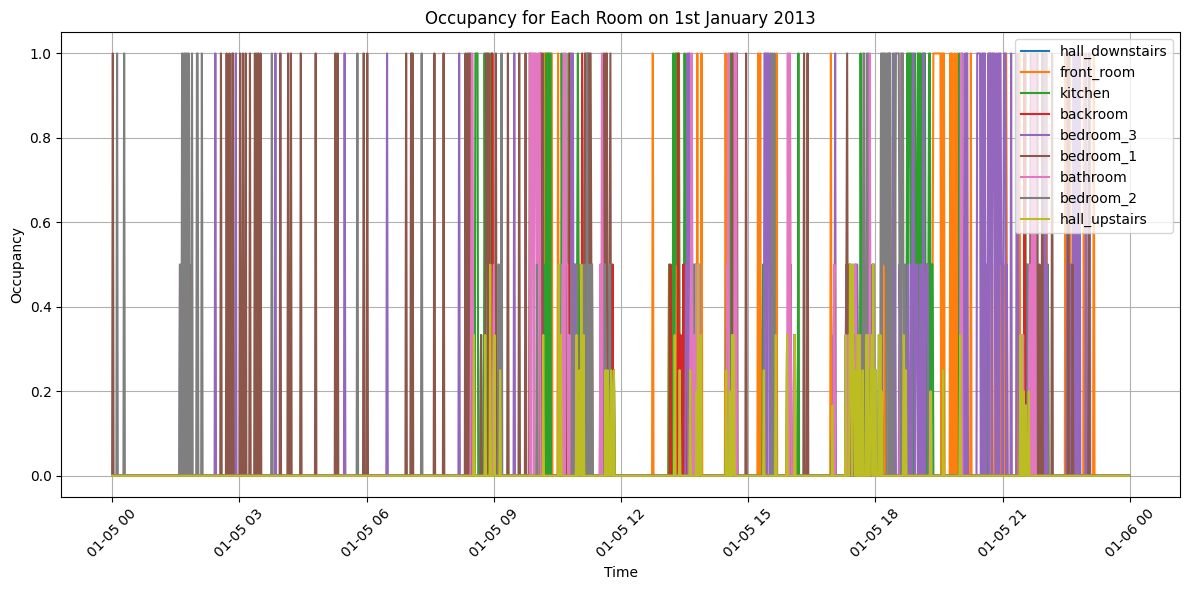

In [4]:
# Filter the DataFrame for a specific day in January
occ['UTC_Time'] = pd.to_datetime(occ['UTC_Time'])
specific_day = occ[(occ['UTC_Time'] >= '2013-01-05') & (occ['UTC_Time'] < '2013-01-06')]

# Plot occupancy for each room
plt.figure(figsize=(12, 6))
for column in specific_day.columns[1:]:
    plt.plot(specific_day['UTC_Time'], specific_day[column], label=column)

plt.title("Occupancy for Each Room on 1st January 2013")
plt.xlabel("Time")
plt.ylabel("Occupancy")
plt.legend(loc="upper right")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [7]:
# Extend occupancy for at least 30 minutes if any occupancy (>0) is detected
extended_df = specific_day.copy()
time_step = pd.to_timedelta('1min')  # Assuming data is at 1-minute intervals
extension_period = pd.to_timedelta('30min')

for column in specific_day.columns[1:]:
    occupancy_times = extended_df[extended_df[column] > 0]['UTC_Time']
    for time in occupancy_times:
        extended_df.loc[(extended_df['UTC_Time'] >= time) &
                        (extended_df['UTC_Time'] < time + extension_period), column] = 1



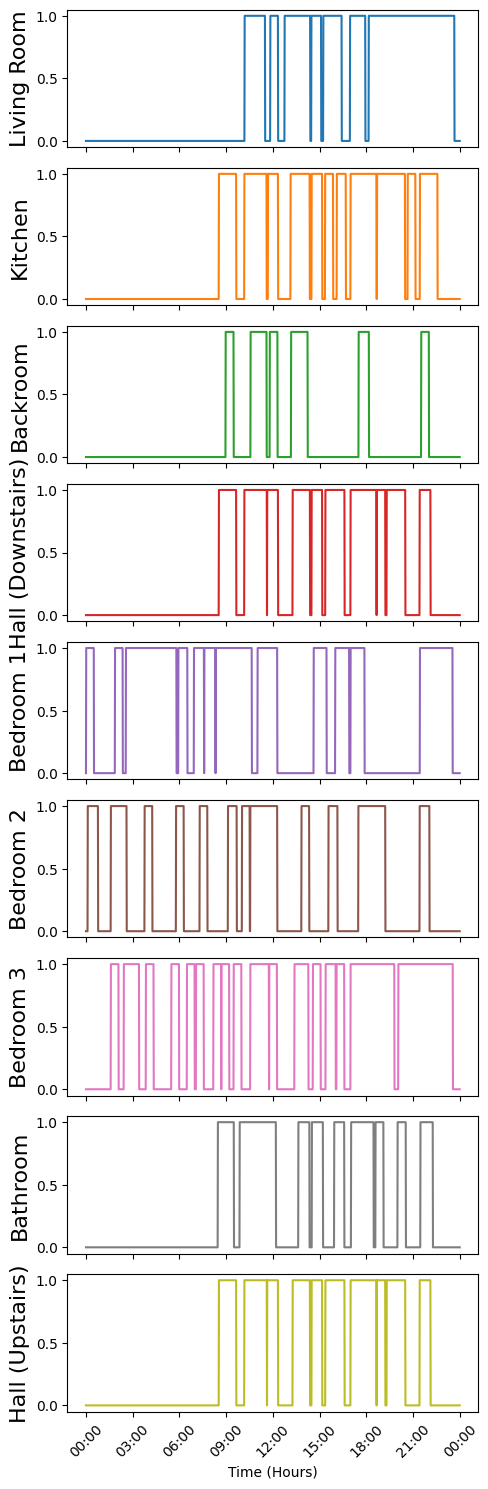

In [10]:
from matplotlib.dates import DateFormatter
import seaborn as sns

room_labels = {
    'front_room': 'Living Room',
    'kitchen': 'Kitchen',
    'backroom': 'Backroom',
    'hall_downstairs': 'Hall (Downstairs)',
    'bedroom_1': 'Bedroom 1',
    'bedroom_2': 'Bedroom 2',
    'bedroom_3': 'Bedroom 3',
    'bathroom': 'Bathroom',
    'hall_upstairs': 'Hall (Upstairs)',
}

colours = sns.color_palette("tab10", n_colors=len(room_labels))

fig, axs = plt.subplots(len(room_labels), 1, figsize=(5, 15), sharex=True)

for i, (room, label) in enumerate(room_labels.items()):
    axs[i].plot(extended_df['UTC_Time'], extended_df[room], color=colours[i])
    axs[i].set_ylabel(label, fontsize=16)

time_formatter = DateFormatter("%H:%M")
axs[-1].xaxis.set_major_formatter(time_formatter)

plt.xlabel("Time (Hours)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
